In [2]:
import pandas as pd

df = pd.read_csv(
    r"E:\datascience\open\datasets\sample_transactions.csv"
)

df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:29,117,80E50C3C0,40653,80FA8F490,4981.60,Swiss Franc,4981.60,Swiss Franc,Cheque,0
1,2022/09/01 13:28,10,8001C6CC0,22828,8010A7DF0,297.72,US Dollar,297.72,US Dollar,Cheque,0
2,2022/09/01 02:46,29191,80CAF3CE0,29191,80CAF3CE0,32.90,Yuan,32.90,Yuan,Reinvestment,0
3,2022/09/02 08:02,10,804DC2C20,14381,80597A020,194634.45,Rupee,194634.45,Rupee,Cheque,0
4,2022/09/09 18:01,16136,80A5EC8A0,16031,80C038E30,698940.91,US Dollar,698940.91,US Dollar,ACH,0


In [3]:
df.shape
df.columns
df.isnull().sum()
df.info()
df["Is Laundering"].value_counts()
df["Payment Format"].value_counts()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Timestamp           200000 non-null  object 
 1   From Bank           200000 non-null  int64  
 2   Account             200000 non-null  object 
 3   To Bank             200000 non-null  int64  
 4   Account.1           200000 non-null  object 
 5   Amount Received     200000 non-null  float64
 6   Receiving Currency  200000 non-null  object 
 7   Amount Paid         200000 non-null  float64
 8   Payment Currency    200000 non-null  object 
 9   Payment Format      200000 non-null  object 
 10  Is Laundering       200000 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 16.8+ MB


Payment Format
Cheque          73373
Credit Card     52194
ACH             23483
Cash            19436
Reinvestment    18930
Wire             6838
Bitcoin          5746
Name: count, dtype: int64

In [4]:
df["Receiving Currency"].value_counts().head(10)
df["Amount Paid"].describe()



count    2.000000e+05
mean     3.086517e+06
std      2.631473e+08
min      1.000000e-06
25%      1.841475e+02
50%      1.419605e+03
75%      1.216135e+04
max      1.079558e+11
Name: Amount Paid, dtype: float64

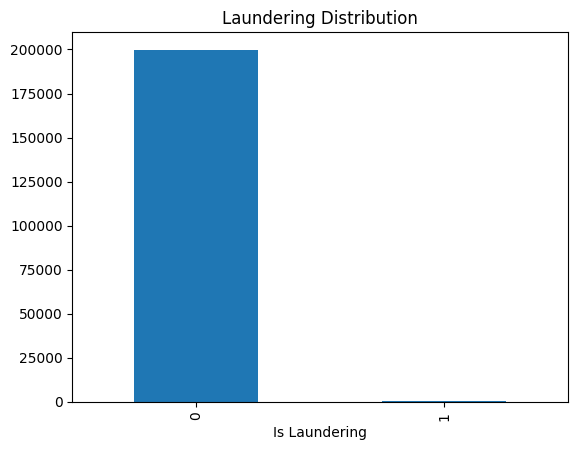

In [5]:
import matplotlib.pyplot as plt

df["Is Laundering"].value_counts().plot(kind="bar")

plt.title("Laundering Distribution")

plt.show()

In [6]:
df.groupby("Receiving Currency")["Amount Paid"].sum().sort_values(ascending=False).head(10)

Receiving Currency
Yen             2.457871e+11
Rupee           1.443217e+11
Ruble           1.206611e+11
US Dollar       3.457031e+10
Mexican Peso    2.438467e+10
Yuan            1.532008e+10
Euro            1.154634e+10
Brazil Real     4.915654e+09
Shekel          4.439208e+09
Saudi Riyal     3.787854e+09
Name: Amount Paid, dtype: float64

In [8]:
df["Is Laundering"].value_counts()
df["Is Laundering"].value_counts(normalize=True) * 100
df.groupby("Is Laundering")["Amount Paid"].mean()


Is Laundering
0    3.088784e+06
1    1.027740e+06
Name: Amount Paid, dtype: float64

Top Risky Currencies

In [19]:
fraud_df = df[df["Is Laundering"] == 1]

fraud_df["Receiving Currency"].value_counts().head(10)

Receiving Currency
US Dollar            91
Euro                 61
Saudi Riyal          15
Yuan                  9
Swiss Franc           9
Rupee                 6
Australian Dollar     5
Yen                   4
Bitcoin               3
Brazil Real           3
Name: count, dtype: int64

Payment Method Fraud Analysis

In [20]:
fraud_df["Payment Format"].value_counts()

Payment Format
ACH            191
Cheque          16
Credit Card      5
Cash             5
Bitcoin          3
Name: count, dtype: int64

High Risk Banks

In [21]:
fraud_df["From Bank"].value_counts().head(10)

From Bank
70        26
20         5
118        5
12         4
11056      3
10         3
28         3
135981     3
1588       3
4403       2
Name: count, dtype: int64

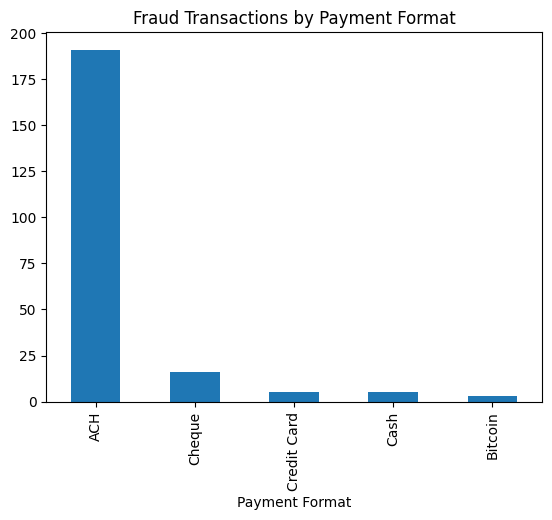

In [22]:
fraud_df["Payment Format"].value_counts().plot(kind="bar")

plt.title("Fraud Transactions by Payment Format")

plt.show()

In [23]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Hour"] = df["Timestamp"].dt.hour


Fraud by Hour

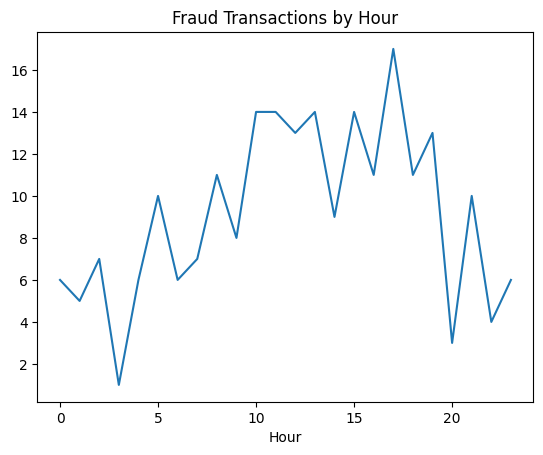

In [24]:
fraud_df.groupby("Hour").size().plot(kind="line")

plt.title("Fraud Transactions by Hour")

plt.show()

In [25]:
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day_name()
df["Month"] = df["Timestamp"].dt.month

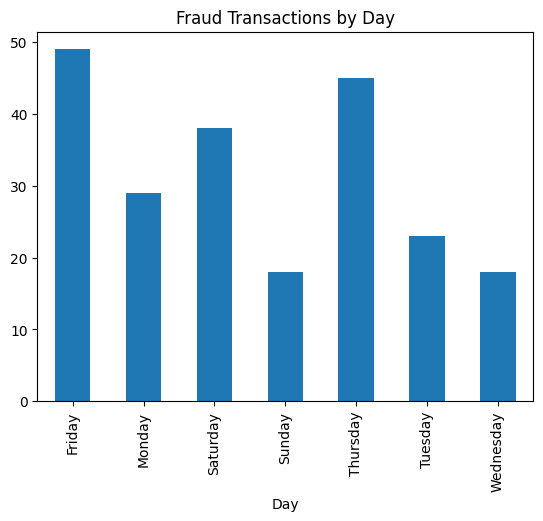

In [26]:
fraud_df.groupby("Day").size().plot(kind="bar")

plt.title("Fraud Transactions by Day")

plt.show()

Highest Fraud Amount Transactions

In [27]:
fraud_df.sort_values(
    by="Amount Paid",
    ascending=False
).head(10)

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Hour,Day,Month
38043,2022-09-04 12:53:00,71,8049DF570,13078,8053B01E0,1.673619e+08,Rupee,1.673619e+08,Rupee,ACH,1,12,Sunday,9
122612,2022-09-05 21:51:00,25981,803330DF0,8888,80DE49790,2.319948e+07,Euro,2.319948e+07,Euro,ACH,1,21,Monday,9
188253,2022-09-10 16:18:00,220541,8083C1550,23833,80426FC30,1.265034e+07,US Dollar,1.265034e+07,US Dollar,ACH,1,16,Saturday,9
59141,2022-09-09 11:00:00,11838,804642430,28255,80BFE6D70,6.467426e+06,US Dollar,6.467426e+06,US Dollar,ACH,1,11,Friday,9
39079,2022-09-06 15:49:00,70,100428660,123102,80D2ACC90,2.314295e+06,US Dollar,2.314295e+06,US Dollar,Cheque,1,15,Tuesday,9
74982,2022-09-10 09:59:00,220,8028EFE80,10057,80C3B78E0,1.870505e+06,Yen,1.870505e+06,Yen,ACH,1,9,Saturday,9
134202,2022-09-10 11:46:00,22164,80236ED50,210261,803B8BFC0,1.461047e+06,Yen,1.461047e+06,Yen,ACH,1,11,Saturday,9
158166,2022-09-06 11:25:00,287,806482430,112931,805D4C850,1.378848e+06,Rupee,1.378848e+06,Rupee,ACH,1,11,Tuesday,9
61159,2022-09-08 10:01:00,210431,809BFD6B0,217096,806DB4BA0,1.306879e+06,Ruble,1.306879e+06,Ruble,ACH,1,10,Thursday,9
80626,2022-09-05 12:04:00,11056,80070EC40,116904,8064A8D40,1.220844e+06,Ruble,1.220844e+06,Ruble,ACH,1,12,Monday,9


Suspicious Accounts

In [28]:
fraud_df["Account"].value_counts().head(10)
fraud_df["Account.1"].value_counts().head(10)

Account.1
811ED7DF0    3
812A09CF0    3
811D80C30    3
80437D050    2
800852F80    2
8106B1750    2
811C599A0    2
80AE68D00    2
810C289B0    2
805D4C850    2
Name: count, dtype: int64

In [29]:
fraud_df.groupby(
    ["Payment Currency", "Receiving Currency"]
).size().sort_values(ascending=False).head(10)

Payment Currency   Receiving Currency
US Dollar          US Dollar             91
Euro               Euro                  61
Saudi Riyal        Saudi Riyal           15
Swiss Franc        Swiss Franc            9
Yuan               Yuan                   9
Rupee              Rupee                  6
Australian Dollar  Australian Dollar      5
Yen                Yen                    4
Ruble              Ruble                  3
Canadian Dollar    Canadian Dollar        3
dtype: int64

save result

In [30]:
df.to_csv(
    r"E:\datascience\open\datasets\processed_transactions.csv",
    index=False
)

Fraud by Payment Format

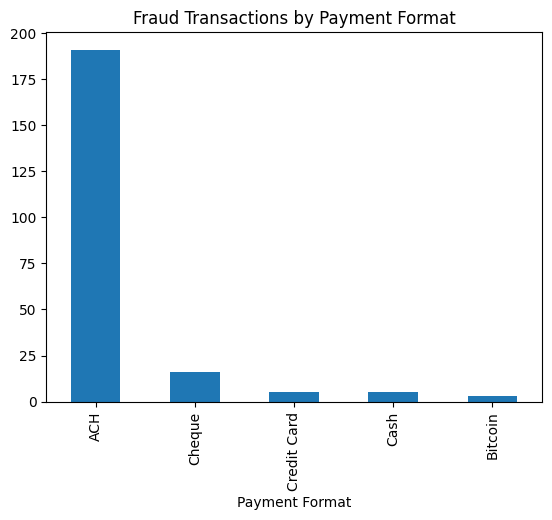

In [31]:
fraud_df["Payment Format"].value_counts()
fraud_df["Payment Format"].value_counts().plot(kind="bar")

plt.title("Fraud Transactions by Payment Format")

plt.show()

Fraud by Currency

In [32]:
fraud_df["Payment Currency"].value_counts().head(10)

Payment Currency
US Dollar            91
Euro                 61
Saudi Riyal          15
Yuan                  9
Swiss Franc           9
Rupee                 6
Australian Dollar     5
Yen                   4
Bitcoin               3
Brazil Real           3
Name: count, dtype: int64

In [33]:
fraud_df.sort_values(
    by="Amount Paid",
    ascending=False
)[[
    "Account",
    "Account.1",
    "Amount Paid",
    "Payment Currency"
]].head(10)

,Account,Account.1,Amount Paid,Payment Currency
38043,8049DF570,8053B01E0,1.673619e+08,Rupee
122612,803330DF0,80DE49790,2.319948e+07,Euro
188253,8083C1550,80426FC30,1.265034e+07,US Dollar
59141,804642430,80BFE6D70,6.467426e+06,US Dollar
39079,100428660,80D2ACC90,2.314295e+06,US Dollar
74982,8028EFE80,80C3B78E0,1.870505e+06,Yen
134202,80236ED50,803B8BFC0,1.461047e+06,Yen
158166,806482430,805D4C850,1.378848e+06,Rupee
61159,809BFD6B0,806DB4BA0,1.306879e+06,Ruble
80626,80070EC40,8064A8D40,1.220844e+06,Ruble


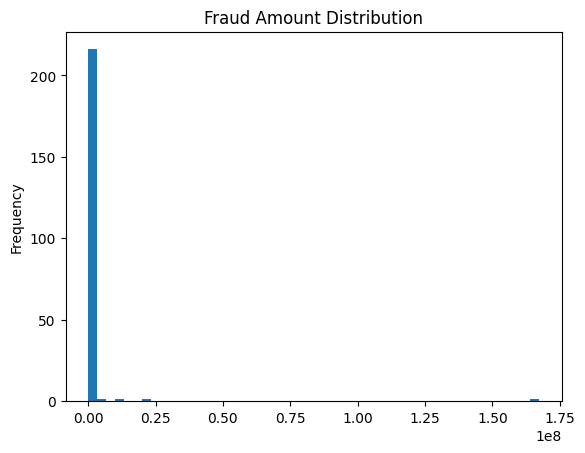

In [34]:
fraud_df["Account"].value_counts().head(10)
fraud_df["Account.1"].value_counts().head(10)
fraud_df["Amount Paid"].plot(
    kind="hist",
    bins=50
)

plt.title("Fraud Amount Distribution")

plt.show()



In [35]:
fraud_df["From Bank"].value_counts().head(10)

From Bank
70        26
20         5
118        5
12         4
11056      3
10         3
28         3
135981     3
1588       3
4403       2
Name: count, dtype: int64

Network Graph Analysis

In [38]:
import networkx as nx
G = nx.from_pandas_edgelist(
    fraud_df.head(1000),
    source="Account",
    target="Account.1",
    edge_attr="Amount Paid",
    create_using=nx.DiGraph()
)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 397
Edges: 217


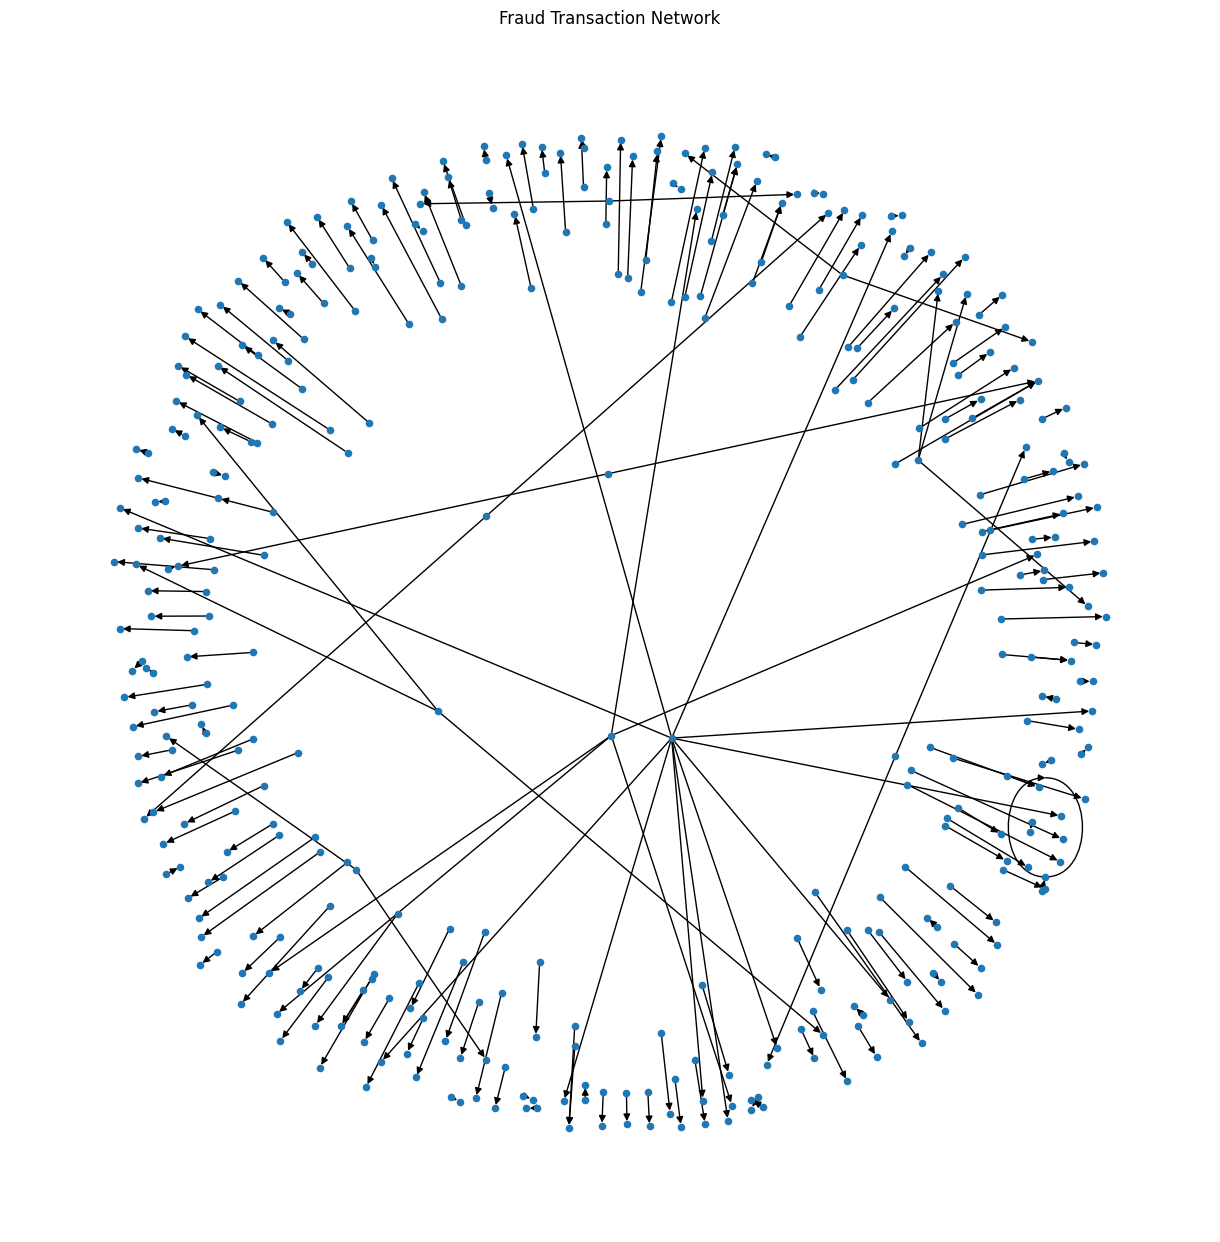

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

nx.draw(
    G,
    node_size=20,
    with_labels=False
)

plt.title("Fraud Transaction Network")

plt.show()

In [40]:
degree_centrality = nx.degree_centrality(G)

sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

[('100428660', 0.02777777777777778),
 ('1004286A8', 0.012626262626262628),
 ('8000B8AB0', 0.007575757575757576),
 ('812A09CF0', 0.007575757575757576),
 ('811D80C30', 0.007575757575757576),
 ('80F984C70', 0.007575757575757576),
 ('800852F80', 0.005050505050505051),
 ('81121FAB0', 0.005050505050505051),
 ('80C6F48A0', 0.005050505050505051),
 ('80F962B10', 0.005050505050505051)]

In [41]:
pagerank = nx.pagerank(G)

sorted(
    pagerank.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

[('812A09CF0', 0.020635230209575854),
 ('811D80C30', 0.005474623337136846),
 ('800852F80', 0.004730035026505171),
 ('81121FAB0', 0.004730035026505171),
 ('8106B1750', 0.004730035026505171),
 ('80437D050', 0.004730035026505171),
 ('80AE68D00', 0.004730035026505171),
 ('810C289B0', 0.004730035026505171),
 ('805D4C850', 0.004730035026505171),
 ('800120A50', 0.0045069070788929105)]

In [42]:
# save
df.to_csv(
    r"E:\datascience\open\datasets\processed_transactions.csv",
    index=False
)

print("Processed dataset saved")

Processed dataset saved


In [43]:
fraud_df.shape[0]
fraud_df["Amount Paid"].sum()
fraud_df["Amount Paid"].mean()
fraud_df["Payment Currency"].value_counts().head(5)
fraud_df["Account"].value_counts().head(10)

Account
100428660    11
1004286A8     5
8000B8AB0     3
811A67510     3
80F984C70     3
1004286F0     2
100428978     2
80F962B10     2
80C6F48A0     2
812A09D40     2
Name: count, dtype: int64

In [44]:
payment_summary = fraud_df.groupby(
    "Payment Format"
)["Amount Paid"].sum().reset_index()

payment_summary.to_csv(
    r"E:\datascience\open\datasets\payment_summary.csv",
    index=False
)

In [45]:
hour_summary = fraud_df.groupby(
    "Hour"
).size().reset_index(name="Fraud Count")

hour_summary.to_csv(
    r"E:\datascience\open\datasets\hour_summary.csv",
    index=False
)